In [1]:
!pip install -r ../requirements.txt

In [2]:
import torch
print(torch.version.cuda)
print(torch.cuda.is_available())

12.8
True


In [3]:
import sys
import importlib
sys.path.append("..")

# Import your modules first
import helper
import obelix
import algorithms.updated_p3_sub6 as d3qn_per_agent
import configurations.config_p3_sub6 as config

# Reload them to pick up any changes
importlib.reload(helper)
importlib.reload(obelix)
importlib.reload(d3qn_per_agent)
importlib.reload(config)

device used:  cuda
device used:  cuda


<module 'configurations.config_p3_sub6' from 'c:\\Users\\hgoel\\MTech_Resources\\DRL\\Capstone_Project\\CS780-OBELIX\\run_scripts\\..\\configurations\\config_p3_sub6.py'>

In [4]:
from helper import plotQuantity
from obelix import OBELIX
from algorithms.updated_p3_sub6 import D3QN_PER
from configurations.config_p3_sub6 import config

In [5]:
print(config)

{'seed': 333, 'gamma': 0.99, 'bufferSize': 1000000, 'batchSize': 32, 'optimizerFn': <class 'torch.optim.adam.Adam'>, 'optimizerLR': 0.0001, 'MAX_TRAIN_EPISODES': 800, 'MAX_EVAL_EPISODES': 5, 'updateFrequency': 80, 'explorationStrategyTrainFn': <function selectEpsilonGreedyActionREP_NOISY at 0x0000013E81F0D620>, 'explorationStrategyEvalFn': <function selectGreedyActionREP_COMP at 0x0000013E81F0D4E0>, 'max_steps': 1000, 'epsilon': 0.98, 'eps_decay_strategy': [('linear', {'s': 0, 'e': 399, 'ival': 1.0, 'fval': 0.35}), ('exponential', {'s': 400, 'e': 799, 'ival': 0.35, 'fval': 0.01})], 'device': device(type='cuda'), 'delta': 0.99, 'tau': 0.005, 'alpha': 0.58, 'beta': 0.42, 'beta_rate': 0.0002, 'f_hDim': [324, 256], 'lstm_hDim': 128, 'model_path': '../model_weights/model_weights_eval_p3_sub6_updated', 'loss_fn': 'HuberLoss', 'seq_len': 30, 'burn_in': 10, 'minSamples': 40, 'for_hDim': [224, 128], 'inv_hDim': [224, 128], 'alpha_f': 0.12, 'beta_i': 0.15, 'eta': 0.07, 'noise_std': 0.22}


In [6]:
env1 = OBELIX(
    scaling_factor=5,
    arena_size=500,
    max_steps=1000,
    wall_obstacles=True,
    difficulty=3,
    box_speed=4,
)

env2 = OBELIX(
    scaling_factor=5,
    arena_size=500,
    max_steps=1000,
    wall_obstacles=False,
    difficulty=3,
    box_speed=4,
)

D3QN_PER_LSTM_with_REP_BAD_HEAD_Agent = D3QN_PER(env1, env2, config)

In [7]:
d3qnPerTrainRewardsList, d3qnPerTrainTimeList, d3qnPerEvalRewardsList1, d3qnPerEvalRewardsList2, d3qnPerWallClockTimeList, d3qnPerTotalStepsList = D3QN_PER_LSTM_with_REP_BAD_HEAD_Agent.runD3QN_PER()

Episode 1: TR(without walls) -15068.000 | TT 9.265 | TS 1000
Episode 2: TR(without walls) -531.000 | TT 9.703 | TS 54
Episode 3: TR(with walls) -39268.000 | TT 18.255 | TS 1000
Episode 4: TR(without walls) -48868.000 | TT 26.276 | TS 1000
Episode 5: TR(with walls) -14460.000 | TT 31.859 | TS 589
Episode 6: TR(without walls) -72393.000 | TT 42.561 | TS 1000
Episode 7: TR(without walls) -2069.000 | TT 53.828 | TS 1000
Episode 8: TR(without walls) -3510.000 | TT 56.700 | TS 240
Episode 9: TR(without walls) -42978.000 | TT 65.261 | TS 706
Episode 10: TR(with walls) -3034.000 | TT 67.121 | TS 166
Episode 11: TR(without walls) -61996.000 | TT 78.813 | TS 1000
Episode 12: TR(with walls) -62480.000 | TT 89.602 | TS 1000
Episode 13: TR(without walls) -2487.000 | TT 99.966 | TS 1000
Episode 14: TR(with walls) -44581.000 | TT 110.306 | TS 1000
Episode 15: TR(without walls) -30679.000 | TT 120.973 | TS 1000
Episode 16: TR(with walls) -38175.000 | TT 131.420 | TS 1000
Episode 17: TR(without walls) 

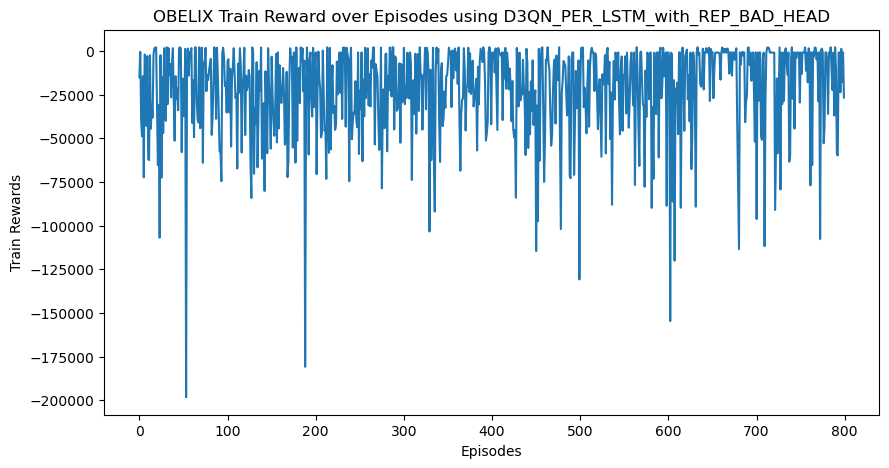

In [8]:
plotQuantity(
    d3qnPerTrainRewardsList,
    len(d3qnPerTrainRewardsList), 
    descriptionList = ["Episodes", "Train Rewards", "OBELIX Train Reward over Episodes using D3QN_PER_LSTM_with_REP_BAD_HEAD"]    
)

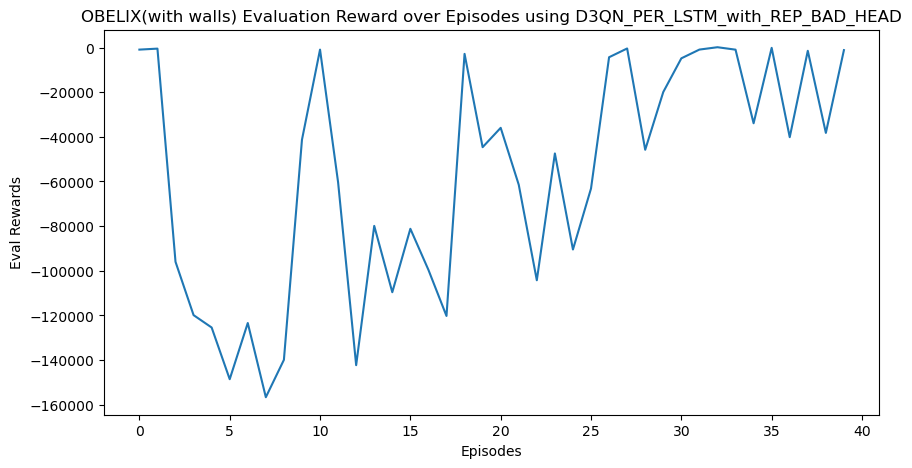

In [9]:
plotQuantity(
    d3qnPerEvalRewardsList1, 
    len(d3qnPerEvalRewardsList1), 
    descriptionList = ["Episodes", "Eval Rewards", "OBELIX(with walls) Evaluation Reward over Episodes using D3QN_PER_LSTM_with_REP_BAD_HEAD"]    
)

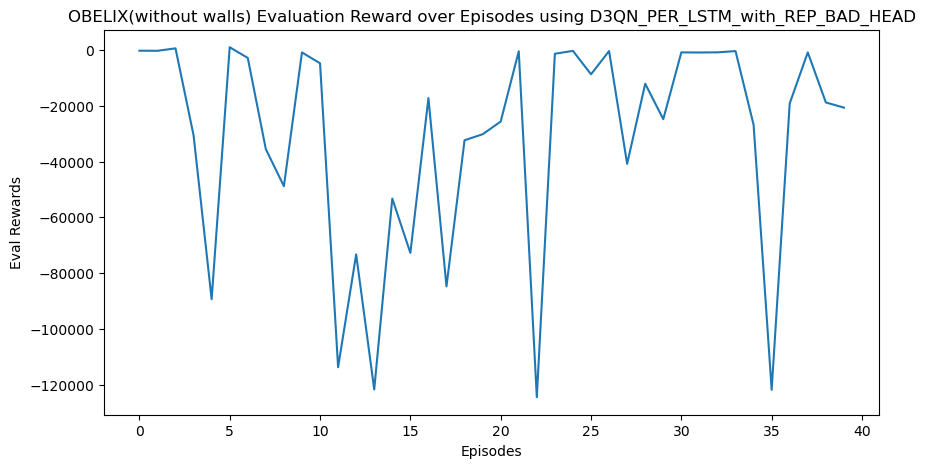

In [10]:
plotQuantity(
    d3qnPerEvalRewardsList2, 
    len(d3qnPerEvalRewardsList2), 
    descriptionList = ["Episodes", "Eval Rewards", "OBELIX(without walls) Evaluation Reward over Episodes using D3QN_PER_LSTM_with_REP_BAD_HEAD"]    
)

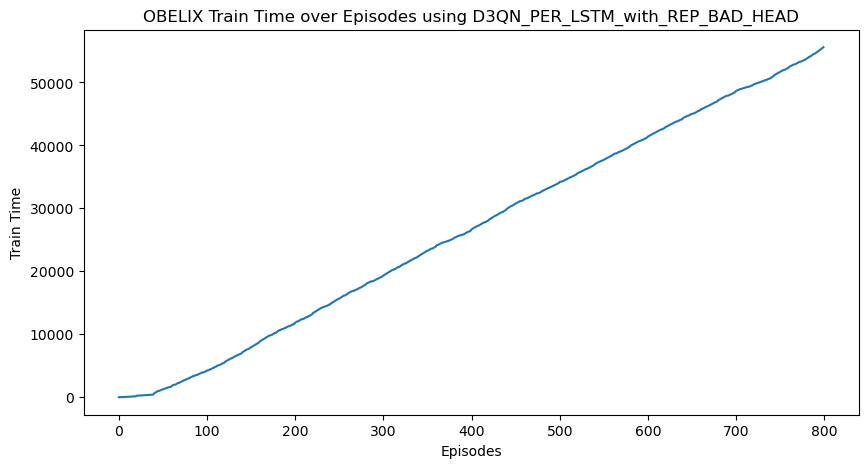

In [11]:
plotQuantity(
    d3qnPerTrainTimeList, 
    len(d3qnPerTrainTimeList), 
    descriptionList = ["Episodes", "Train Time", "OBELIX Train Time over Episodes using D3QN_PER_LSTM_with_REP_BAD_HEAD"]    
)

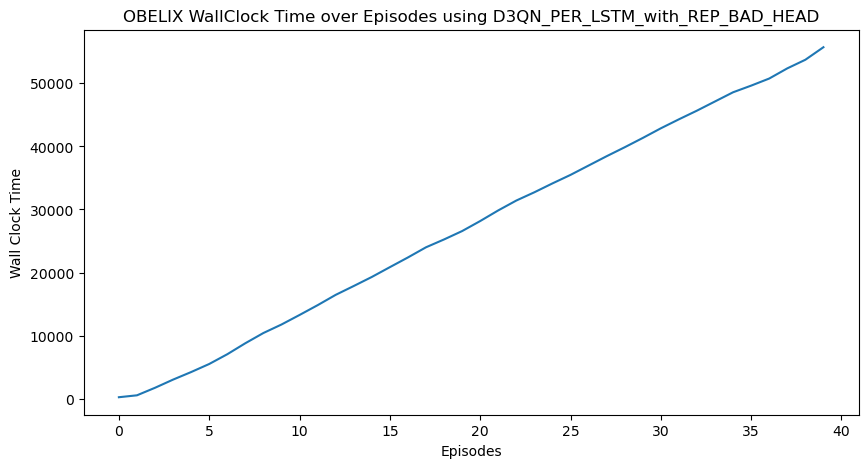

In [12]:
plotQuantity(
    d3qnPerWallClockTimeList, 
    len(d3qnPerWallClockTimeList), 
    descriptionList = ["Episodes", "Wall Clock Time", "OBELIX WallClock Time over Episodes using D3QN_PER_LSTM_with_REP_BAD_HEAD"]    
)

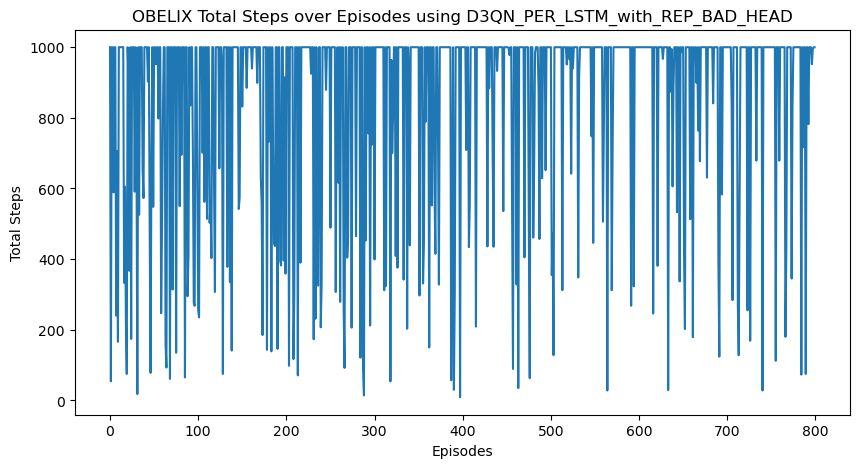

In [13]:
plotQuantity(
    d3qnPerTotalStepsList, 
    len(d3qnPerTotalStepsList), 
    descriptionList = ["Episodes", "Total Steps", "OBELIX Total Steps over Episodes using D3QN_PER_LSTM_with_REP_BAD_HEAD"]    
)